## Test

In [1]:
import numpy as np
import pandas as pd

# 加载 .npz 文件
for chi in [16,32,64,128]:
    data = np.load('../singleset/Holstein75_{}bd_krylov32.npz'.format(chi),allow_pickle=True)

    # 'mol list', 'tempearture', 'total time', 'other info', 'r square array', 
    # 'electron occupations array', 'phonon occupations array', 'k occupations array', 
    # 'eph entropy', 'bond entropy', 'coherent length array', 'time series'
    df = data['electron occupations array']

    df = pd.DataFrame(df)

    df.to_excel('../singleset/Holstein75_{}bd_singleset_krylov32.xlsx'.format(chi), index=False)

## Plot RMSD



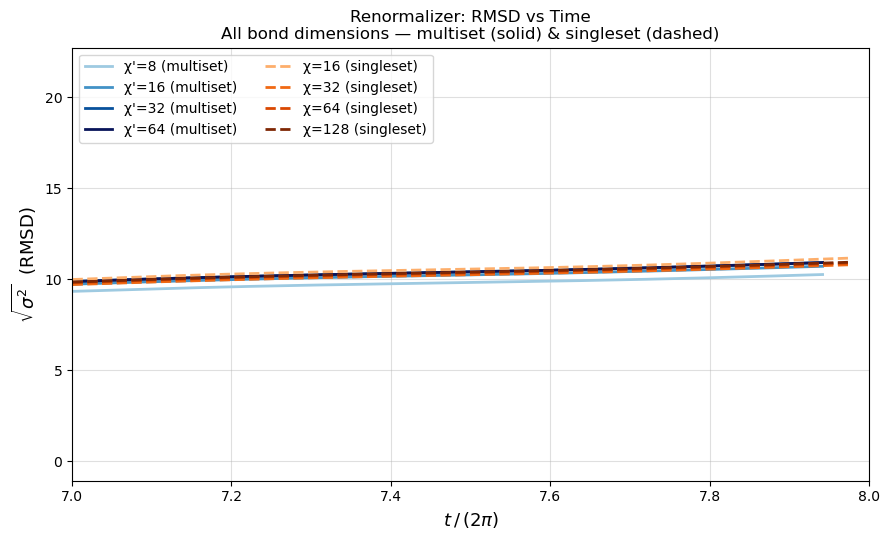

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 基本参数
# =========================
dt = 0.1  # a.u.

# =========================
# 计算 RMSD 的函数
# =========================
def compute_rmsd(file_path):
    df = pd.read_excel(file_path, header=None)
    occup = df.values  # shape: (Nt, Nsite)

    Nt, Nsite = occup.shape
    n0 = (Nsite - 1) / 2
    x = np.arange(Nsite)

    rmsd = np.zeros(Nt)
    for t in range(Nt):
        rho = occup[t]
        norm = np.sum(rho)
        if norm > 0:
            rho = rho / norm
        rmsd[t] = np.sqrt(np.sum((x - n0)**2 * rho))

    time_au = np.arange(Nt) * dt
    time_scaled = time_au / (2 * np.pi)
    return time_scaled, rmsd

# =========================
# 收集所有涉及的文件（去重），并标注来源组
# =========================

# multiset 组所有文件（按 bond dim 从小到大）
files_multiset = [
    ("χ'=8",   "../multiset/Holstein75_8bd_multiset.xlsx"),
    ("χ'=16",  "../multiset/Holstein75_16bd_multiset.xlsx"),
    ("χ'=32",  "../multiset/Holstein75_32bd_multiset.xlsx"),
    ("χ'=64",  "../multiset/Holstein75_64bd_multiset.xlsx"),   # 作为 χ'=32 的参考，也画出来
]

# singleset 组所有文件（按 bond dim 从小到大）
files_singleset = [
    ("χ=16",   "../singleset/Holstein75_16bd_singleset_krylov32.xlsx"),
    ("χ=32",   "../singleset/Holstein75_32bd_singleset_krylov32.xlsx"),
    ("χ=64",   "../singleset/Holstein75_64bd_singleset_krylov32.xlsx"),
    ("χ=128",  "../singleset/Holstein75_128bd_singleset_krylov32.xlsx"),  # 作为 χ=64 的参考，也画出来
]

# =========================
# 颜色配置
# multiset:  实线，蓝绿色系，bond dim 从小到大颜色从浅到深
# singleset: 虚线，橙红色系，bond dim 从小到大颜色从浅到深
# =========================
colors_multiset  = ["#9ecae1", "#4292c6", "#08519c", "#08145a"]  # 浅蓝→深蓝
colors_singleset = ["#fdae6b", "#f16913", "#d94801", "#7f2704"]  # 浅橙→深橙

# =========================
# 绘图：所有文件的 RMSD
# =========================
fig, ax = plt.subplots(figsize=(9, 5.5))

# --- multiset 组（实线）---
for (label, file_path), color in zip(files_multiset, colors_multiset):
    try:
        time, rmsd = compute_rmsd(file_path)
        ax.plot(time, rmsd, lw=2, ls="-", color=color, label=f"{label} (multiset)")
    except FileNotFoundError:
        print(f"[Warning] 文件未找到，已跳过：{file_path}")

# --- singleset 组（虚线）---
for (label, file_path), color in zip(files_singleset, colors_singleset):
    try:
        time, rmsd = compute_rmsd(file_path)
        ax.plot(time, rmsd, lw=2, ls="--", color=color, label=f"{label} (singleset)")
    except FileNotFoundError:
        print(f"[Warning] 文件未找到，已跳过：{file_path}")

# =========================
# 图像设置
# =========================
ax.set_xlim(left=7,right=8)
# ax.set_ylim(bottom=8, top=11)
ax.set_xlabel(r"$t\,/\,(2\pi)$", fontsize=13)
ax.set_ylabel(r"$\sqrt{\sigma^2}$  (RMSD)", fontsize=13)
ax.set_title("Renormalizer: RMSD vs Time\n"
             "All bond dimensions — multiset (solid) & singleset (dashed)",
             fontsize=12)
ax.legend(fontsize=10, ncol=2, loc="upper left")
ax.grid(True, which="both", alpha=0.4)
plt.tight_layout()
# plt.savefig("All_RMSD.png", dpi=150)
plt.show()

## related error


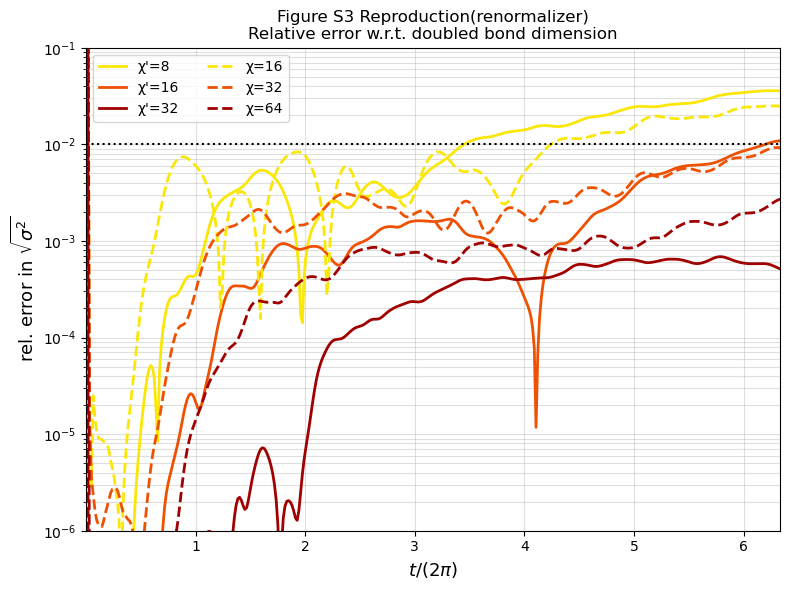

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 基本参数
# =========================
dt = 0.1  # a.u.

# =========================
# 计算 RMSD 的函数
# =========================
def compute_rmsd(file_path):
    df = pd.read_excel(file_path, header=None)
    occup = df.values  # shape: (Nt, Nsite)

    Nt, Nsite = occup.shape
    n0 = (Nsite - 1) / 2
    x = np.arange(Nsite)

    rmsd = np.zeros(Nt)
    for t in range(Nt):
        rho = occup[t]
        norm = np.sum(rho)
        if norm > 0:
            rho = rho / norm
        rmsd[t] = np.sqrt(np.sum((x - n0)**2 * rho))

    time_au = np.arange(Nt) * dt
    time_scaled = time_au / (2 * np.pi)
    return time_scaled, rmsd

# =========================
# 文件定义：(低bd文件, 参考=2倍bd文件)
# 严格按照文章：每条曲线的参考是其翻倍bd的计算
# =========================

# multiset 组：参考是翻倍的 multiset
pairs_multiset = [
    ("χ'=8",  "../multiset/Holstein75_8bd_multiset.xlsx",   "../multiset/Holstein75_16bd_multiset.xlsx"),
    ("χ'=16", "../multiset/Holstein75_16bd_multiset.xlsx",  "../multiset/Holstein75_32bd_multiset.xlsx"),
    ("χ'=32", "../multiset/Holstein75_32bd_multiset.xlsx",  "../multiset/Holstein75_64bd_multiset.xlsx"),
]

# singleset 组：参考是翻倍的 singleset
pairs_singleset = [
    ("χ=16",  "../singleset/Holstein75_16bd_singleset_krylov32.xlsx",  "../singleset/Holstein75_32bd_singleset_krylov32.xlsx"),
    ("χ=32",  "../singleset/Holstein75_32bd_singleset_krylov32.xlsx",  "../singleset/Holstein75_64bd_singleset_krylov32.xlsx"),
    ("χ=64",  "../singleset/Holstein75_64bd_singleset_krylov32.xlsx",  "../singleset/Holstein75_128bd_singleset_krylov32.xlsx"),
]

# =========================
# 颜色与线型（对照文章 S3 图）
# multiset: 实线，冷色系（文章中 multiset 是 solid）
# singleset: 虚线，暖色系（文章中 singleset 是 dashed）
# =========================
colors_multiset  = ["#fbe707", "#ef5102", "#A10000"]   # 
colors_singleset = ["#fbe707", "#ef5102", "#A10000"]   # 

# =========================
# 绘图
# =========================
fig, ax = plt.subplots(figsize=(8, 6))

# --- multiset 组（实线）---
for (label, file_low, file_ref), color in zip(pairs_multiset, colors_multiset):
    time, rmsd_low = compute_rmsd(file_low)
    _,    rmsd_ref = compute_rmsd(file_ref)

    n = min(len(rmsd_low), len(rmsd_ref))

    # 关键修正：避免 t=0 除零；从 t=1 步开始（跳过 t=0）
    # 或者使用 np.where 处理
    denom = np.abs(rmsd_ref[:n])
    numer = np.abs(rmsd_low[:n] - rmsd_ref[:n])

    # 避免除零：分母为0的地方设为nan
    with np.errstate(invalid='ignore', divide='ignore'):
        rel_err = np.where(denom > 1e-10, numer / denom, np.nan)

    ax.plot(time[:n], rel_err, lw=2, ls="-", color=color, label=label)

# --- singleset 组（虚线）---
for (label, file_low, file_ref), color in zip(pairs_singleset, colors_singleset):
    time, rmsd_low = compute_rmsd(file_low)
    _,    rmsd_ref = compute_rmsd(file_ref)

    n = min(len(rmsd_low), len(rmsd_ref))

    denom = np.abs(rmsd_ref[:n])
    numer = np.abs(rmsd_low[:n] - rmsd_ref[:n])

    with np.errstate(invalid='ignore', divide='ignore'):
        rel_err = np.where(denom > 1e-10, numer / denom, np.nan)

    ax.plot(time[:n], rel_err, lw=2, ls="--", color=color, label=label)

# =========================
# 1% 收敛阈值线（文章中的黑色虚线）
# =========================
ax.axhline(0.01, color="k", ls=":", lw=1.5)

# =========================
# 图像设置
# =========================
ax.set_yscale("log")   # 文章 S3 纵轴是对数坐标！
ax.set_xlim(1e-5, 6.333)
ax.set_ylim(1e-6, 1e-1)
ax.set_xlabel(r"$t / (2\pi)$", fontsize=13)
ax.set_ylabel(r"rel. error in $\sqrt{\sigma^2}$", fontsize=13)
ax.set_title("Figure S3 Reproduction(renormalizer)\n"
             r"Relative error w.r.t. doubled bond dimension")
ax.legend(fontsize=10, ncol=2)
ax.grid(True, which="both", alpha=0.4)
plt.tight_layout()
# plt.savefig("FigS3_reproduced.png", dpi=150)
plt.show()

## MAE


### Renormalizer singleset substep RMSD

In [4]:
def load_occupation_table(path, dt=dt):
    try:
        df = pd.read_excel(path, sheet_name='populations')
        site_cols = [col for col in df.columns if str(col).startswith('site_')]
        if site_cols:
            if 'time' in df.columns:
                time_au = pd.to_numeric(df['time'], errors='coerce').to_numpy(dtype=float)
            else:
                time_au = np.arange(len(df), dtype=float) * dt
            occup = df[site_cols].apply(pd.to_numeric, errors='coerce').to_numpy(dtype=float)
            occup = np.nan_to_num(occup, copy=False)
            return time_au, occup
    except ValueError:
        pass

    df = pd.read_excel(path, header=None)
    if np.array_equal(df.iloc[0].to_numpy(), np.arange(df.shape[1])):
        df = df.iloc[1:].reset_index(drop=True)
    occup = df.to_numpy(dtype=float)
    time_au = np.arange(occup.shape[0], dtype=float) * dt
    return time_au, occup

def compute_rmsd_from_occupations(time_au, occup):
    nt, nsite = occup.shape
    n0 = (nsite - 1) / 2
    x = np.arange(nsite, dtype=float)

    norm = occup.sum(axis=1, keepdims=True)
    rho = np.divide(occup, norm, out=np.zeros_like(occup), where=norm > 0)
    rmsd = np.sqrt(((x - n0) ** 2 * rho).sum(axis=1))
    return time_au / (2 * np.pi), rmsd

zoom_window = (7.8, 8.0)

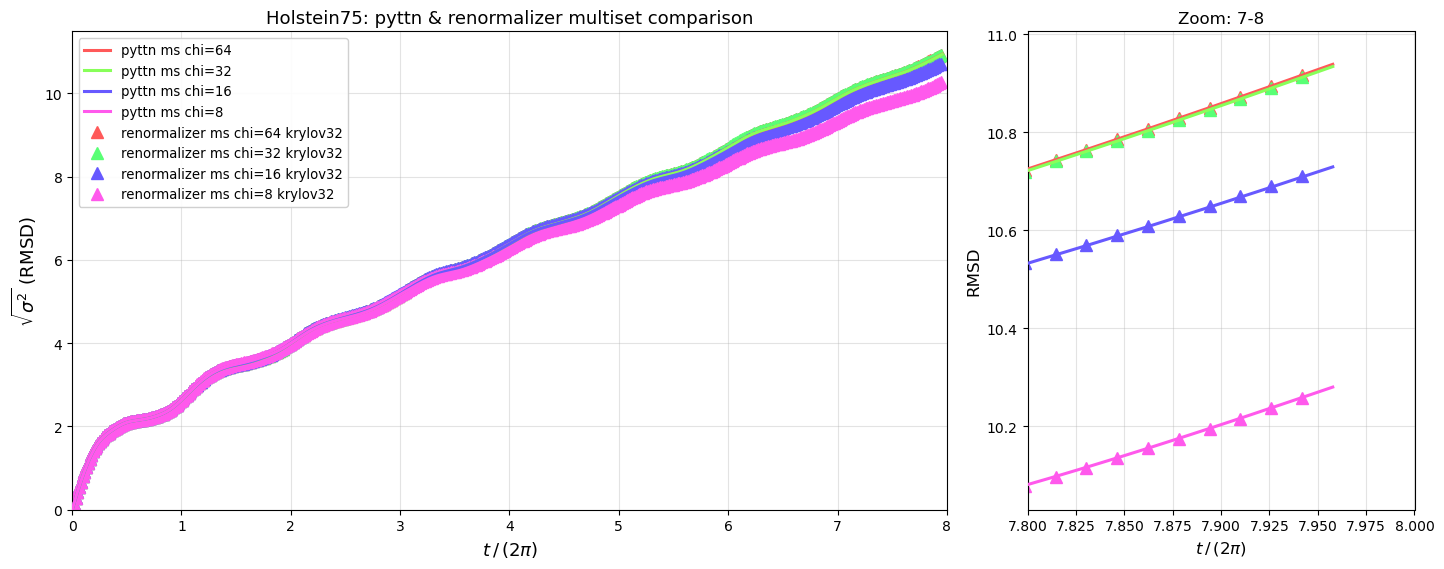

In [5]:
from pathlib import Path
pyttn_plot_dir = Path('../../../../pyttn/test_multiset/Holstein75/plot')
renorm_plot_dir = Path('../multiset') 

comparison_files = [
    {
        'label': 'pyttn ms chi=64',
        'path': pyttn_plot_dir / 'holstein75_multiset_chi64.xlsx',
        'library': 'pyttn',
        'color': "#FF5959",
        'linestyle': '-',
        'linewidth': 2.2,
        'zorder': 3,
    },
    {
        'label': 'pyttn ms chi=32',
        'path': pyttn_plot_dir / 'holstein75_multiset_chi32.xlsx',
        'library': 'pyttn',
        'color': "#88FF59",
        'linestyle': '-',
        'linewidth': 2.2,
        'zorder': 3,
    },
    {
        'label': 'pyttn ms chi=16',
        'path': pyttn_plot_dir / 'holstein75_multiset_chi16.xlsx',
        'library': 'pyttn',
        'color': "#6759FF",
        'linestyle': '-',
        'linewidth': 2.2,
        'zorder': 3,
    },
    {
        'label': 'pyttn ms chi=8',
        'path': pyttn_plot_dir / 'holstein75_multiset_chi8.xlsx',
        'library': 'pyttn',
        'color': "#FF59EC",
        'linestyle': '-',
        'linewidth': 2.2,
        'zorder': 3,
    },
    ###################################################################################################
    {
        'label': 'renormalizer ms chi=64 krylov32',
        'path': renorm_plot_dir / 'Holstein75_64bd_multiset.xlsx',
        'library': 'renormalizer',
        'color': "#FF5959",
        'marker': '^',
        'markersize': 8.5,
        'zorder': 2,
    },
    {
        'label': 'renormalizer ms chi=32 krylov32',
        'path': renorm_plot_dir / 'Holstein75_32bd_multiset.xlsx',
        'library': 'renormalizer',
        'color': "#59FF75",
        'marker': '^',
        'markersize': 8.5,
        'zorder': 2,
    },
    {
        'label': 'renormalizer ms chi=16 krylov32',
        'path': renorm_plot_dir / 'Holstein75_16bd_multiset.xlsx',
        'library': 'renormalizer',
        'color': "#6759FF",
        'marker': '^',
        'markersize': 8.5,
        'zorder': 2,
    },
    {
        'label': 'renormalizer ms chi=8 krylov32',
        'path': renorm_plot_dir / 'Holstein75_8bd_multiset.xlsx',
        'library': 'renormalizer',
        'color': "#FF59EC",
        'marker': '^',
        'markersize': 8.5,
        'zorder': 2,
    },
]

fig, (ax, ax_zoom) = plt.subplots(
    1,
    2,
    figsize=(14.5, 5.8),
    gridspec_kw={'width_ratios': [2.6, 1.15]},
)

x_max = 0.0
zoom_values = []

for item in comparison_files:
    time_au, occup = load_occupation_table(item['path'])
    time, rmsd = compute_rmsd_from_occupations(time_au, occup)
    x_max = max(x_max, float(time.max()))
    if item['library'] == 'pyttn':
        ax.plot(time, rmsd, color=item['color'], linestyle=item['linestyle'], linewidth=item['linewidth'], zorder=item['zorder'], label=item['label'])
        ax_zoom.plot(time, rmsd, color=item['color'], linestyle=item['linestyle'], linewidth=item['linewidth'], zorder=item['zorder'])
    else:
        ax.plot(time, rmsd, color=item['color'], linestyle='None', marker=item['marker'], markersize=item['markersize'], zorder=item['zorder'], label=item['label'])
        ax_zoom.plot(time, rmsd, color=item['color'], linestyle='None', marker=item['marker'], markersize=item['markersize'], zorder=item['zorder'])
    mask = (time >= zoom_window[0]) & (time <= zoom_window[1])
    if np.any(mask):
        zoom_values.append(rmsd[mask])

ax.set_xlim(0, max(x_max, zoom_window[1]))
ax.set_ylim(bottom=0)
ax.set_xlabel(r'$t\,/\,(2\pi)$', fontsize=13)
ax.set_ylabel(r'$\sqrt{\sigma^2}$ (RMSD)', fontsize=13)
ax.set_title('Holstein75: pyttn & renormalizer multiset comparison', fontsize=13)
ax.grid(True, which='both', alpha=0.35)

ax_zoom.set_xlim(*zoom_window)
if zoom_values:
    zoom_concat = np.concatenate(zoom_values)
    y_min = float(zoom_concat.min())
    y_max = float(zoom_concat.max())
    pad = max(0.01, 0.08 * (y_max - y_min))
    ax_zoom.set_ylim(max(0, y_min - pad), y_max + pad)
ax_zoom.set_xlabel(r'$t\,/\,(2\pi)$', fontsize=12)
ax_zoom.set_ylabel('RMSD', fontsize=12)
ax_zoom.set_title('Zoom: 7-8', fontsize=12)
ax_zoom.grid(True, which='both', alpha=0.35)

ax.legend(fontsize=9.5, loc='upper left', frameon=True, framealpha=0.92)
fig.tight_layout()
plt.show()
